# WIPS Preflight Investigation
## OSHA ITA Manufacturing Dataset — 2024

**Author:** Billy R. Davis | IRMB Research | April 2026

Tests whether public OSHA data contains signal to identify
manufacturing facilities with elevated injury risk.
This is a validation exercise, not a production system.

**Key finding:** Prior year injury trajectory is the
strongest predictive signal. Medium facilities (50–249
employees) show High Risk F1 = 0.882 on held-out data.

**Honest limitation:** This system classifies historical
patterns. It does not predict future risk in real time.
Company-specific data is required for the next phase.


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
from google.colab import files
uploaded = files.upload()

Saving ITA_300A_Summary_Data_2024_through_12-31-2025.zip to ITA_300A_Summary_Data_2024_through_12-31-2025 (1).zip


In [17]:
import pandas as pd

df = pd.read_csv('ITA_300A_Summary_Data_2024_through_12-31-2025.zip',
                 low_memory=False)

print(df.shape)
print(df['naics_code'].value_counts().head(20))
print(df['state'].value_counts().head(10))
print(df[['total_deaths','total_dafw_cases','total_injuries']].describe())
print(df.isnull().sum())

(398620, 32)
naics_code
445110    18730
722310    13549
455219    13267
491110     9264
623110     9200
493110     8146
721110     6497
444110     6334
561720     5556
492110     5552
238220     5022
236220     4922
622110     4786
623312     4718
238210     4220
452910     4152
561210     4087
237310     3611
621111     3167
621610     3101
Name: count, dtype: int64
state
CA    40449
TX    31106
FL    21656
PA    17030
IL    16829
OH    16817
NY    16609
NC    14343
MI    13926
MN    12470
Name: count, dtype: int64
        total_deaths  total_dafw_cases  total_injuries
count  398620.000000     398620.000000   398620.000000
mean        0.002037          1.317024        3.461334
std         0.051381          7.238057       15.914041
min         0.000000          0.000000        0.000000
25%         0.000000          0.000000        0.000000
50%         0.000000          0.000000        1.000000
75%         0.000000          1.000000        3.000000
max        11.000000       1113.000000

In [18]:
# Filter manufacturing (NAICS 31-33)
mfg = df[df['naics_code'].astype(str).str.startswith(('31','32','33'))]

print(f"Manufacturing records: {len(mfg)}")

# Calculate injury rate per 100 workers
mfg = mfg.copy()
mfg['injury_rate'] = (mfg['total_injuries'] /
                      mfg['annual_average_employees'].replace(0, 1)) * 100

print(mfg['injury_rate'].describe())
print(f"\nHigh risk facilities (rate > 10): {(mfg['injury_rate'] > 10).sum()}")

Manufacturing records: 62060
count    62060.000000
mean         3.364820
std         41.289734
min          0.000000
25%          0.000000
50%          1.785714
75%          4.324324
max      10000.000000
Name: injury_rate, dtype: float64

High risk facilities (rate > 10): 3601


In [19]:
# Remove impossible injury rates
# Cap at 100 injuries per 100 workers as reasonable ceiling
mfg_clean = mfg[
    (mfg['injury_rate'] < 100) &
    (mfg['annual_average_employees'] >= 5) &
    (mfg['total_hours_worked'] > 0)
].copy()

print(f"Records after cleaning: {len(mfg_clean)}")
print(f"Removed: {len(mfg) - len(mfg_clean)}")
print(f"\nInjury rate after cleaning:")
print(mfg_clean['injury_rate'].describe())
print(f"\nHigh risk facilities (rate > 10): {(mfg_clean['injury_rate'] > 10).sum()}")

Records after cleaning: 60702
Removed: 1358

Injury rate after cleaning:
count    60702.000000
mean         3.098835
std          4.236619
min          0.000000
25%          0.000000
50%          1.869159
75%          4.347826
max         86.666667
Name: injury_rate, dtype: float64

High risk facilities (rate > 10): 3488


In [20]:
import numpy as np

# Create risk tiers for classification target
def classify_risk(rate):
    if rate == 0:
        return 0  # No recorded injuries
    elif rate <= 3:
        return 1  # Low risk
    elif rate <= 10:
        return 2  # Medium risk
    else:
        return 3  # High risk

mfg_clean['risk_tier'] = mfg_clean['injury_rate'].apply(classify_risk)

print("Risk tier distribution:")
print(mfg_clean['risk_tier'].value_counts().sort_index())
print("\nAs percentage:")
print((mfg_clean['risk_tier'].value_counts(normalize=True)
       .sort_index() * 100).round(2))

Risk tier distribution:
risk_tier
0    19144
1    19277
2    18793
3     3488
Name: count, dtype: int64

As percentage:
risk_tier
0    31.54
1    31.76
2    30.96
3     5.75
Name: proportion, dtype: float64


In [21]:
# Select modeling features
features = [
    'naics_code',
    'size',
    'annual_average_employees',
    'total_hours_worked',
    'state',
    'year_filing_for'
]

target = 'risk_tier'

X = mfg_clean[features].copy()
y = mfg_clean[target].copy()

# Check for nulls in features
print("Null counts in features:")
print(X.isnull().sum())
print(f"\nFeature matrix shape: {X.shape}")
print(f"\nSample rows:")
print(X.head())

Null counts in features:
naics_code                  0
size                        0
annual_average_employees    0
total_hours_worked          0
state                       0
year_filing_for             0
dtype: int64

Feature matrix shape: (60702, 6)

Sample rows:
    naics_code  size  annual_average_employees  total_hours_worked state  \
1       311421    22                       119               98259    GA   
6       331110     2                       119              276569    PA   
8       332323    21                        45              100087    UT   
11      332312    21                        44               88758    AL   
18      325920     2                        43               77678    KS   

    year_filing_for  
1              2024  
6              2024  
8              2024  
11             2024  
18             2024  


In [22]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Encode categorical columns
X_encoded = X.copy()
le_state = LabelEncoder()
le_naics = LabelEncoder()

X_encoded['state'] = le_state.fit_transform(X['state'])
X_encoded['naics_code'] = le_naics.fit_transform(X['naics_code'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Baseline Random Forest
clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Risk','Low','Medium','High']))

# Feature importance
import pandas as pd
importances = pd.Series(clf.feature_importances_,
                        index=X_encoded.columns)
print("\nFeature Importance:")
print(importances.sort_values(ascending=False))

Training set: (48561, 6)
Test set: (12141, 6)

Classification Report:
              precision    recall  f1-score   support

     No Risk       0.55      0.61      0.58      3829
         Low       0.56      0.64      0.60      3855
      Medium       0.42      0.38      0.40      3759
        High       0.21      0.03      0.06       698

    accuracy                           0.51     12141
   macro avg       0.43      0.42      0.41     12141
weighted avg       0.49      0.51      0.50     12141


Feature Importance:
total_hours_worked          0.319747
naics_code                  0.238443
annual_average_employees    0.235454
state                       0.174735
size                        0.031620
year_filing_for             0.000000
dtype: float64


## ⚠️ Data Leakage — Identified and Corrected

An earlier feature engineering version used
injury-derived columns to predict injury risk.
That version produced 97% accuracy and was wrong.

The model was reconstructing the label from its
own ingredients — not learning to predict risk.

All injury-derived features removed going forward.
Only pre-incident features are used from this point.

In [23]:
# Engineer better features from existing data
mfg_clean = mfg_clean.copy()

# Injury rate per hour worked (normalized exposure)
mfg_clean['injury_per_hour'] = (
    mfg_clean['total_injuries'] /
    mfg_clean['total_hours_worked'].replace(0,1)
) * 200000  # OSHA standard rate per 200k hours

# Severity ratio - days away vs total cases
mfg_clean['severity_ratio'] = (
    mfg_clean['total_dafw_days'] /
    mfg_clean['total_injuries'].replace(0,1)
)

# Illness vs injury mix
mfg_clean['illness_ratio'] = (
    (mfg_clean['total_skin_disorders'] +
     mfg_clean['total_respiratory_conditions'] +
     mfg_clean['total_poisonings']) /
    mfg_clean['total_injuries'].replace(0,1)
)

# Cases per employee
mfg_clean['cases_per_employee'] = (
    mfg_clean['total_dafw_cases'] /
    mfg_clean['annual_average_employees'].replace(0,1)
)

# Update features and retrain
features_v2 = [
    'naics_code', 'size', 'annual_average_employees',
    'total_hours_worked', 'state', 'year_filing_for',
    'injury_per_hour', 'severity_ratio',
    'illness_ratio', 'cases_per_employee'
]

X2 = mfg_clean[features_v2].copy()
X2['state'] = le_state.transform(mfg_clean['state'])
X2['naics_code'] = le_naics.transform(mfg_clean['naics_code'])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)

clf2 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf2.fit(X2_train, y2_train)
y2_pred = clf2.predict(X2_test)

print("Classification Report v2:")
print(classification_report(y2_test, y2_pred,
      target_names=['No Risk','Low','Medium','High']))

importances2 = pd.Series(clf2.feature_importances_,
                         index=X2.columns)
print("\nFeature Importance v2:")
print(importances2.sort_values(ascending=False))

Classification Report v2:
              precision    recall  f1-score   support

     No Risk       1.00      1.00      1.00      3829
         Low       0.98      0.96      0.97      3855
      Medium       0.94      0.96      0.95      3759
        High       0.92      0.88      0.90       698

    accuracy                           0.97     12141
   macro avg       0.96      0.95      0.96     12141
weighted avg       0.97      0.97      0.97     12141


Feature Importance v2:
injury_per_hour             0.692131
cases_per_employee          0.093414
annual_average_employees    0.075743
total_hours_worked          0.054353
severity_ratio              0.043429
naics_code                  0.015354
size                        0.011704
state                       0.011262
illness_ratio               0.002610
year_filing_for             0.000000
dtype: float64


In [24]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Clean features only - no outcome-derived columns
features_v3 = [
    'naics_code',
    'size',
    'annual_average_employees',
    'total_hours_worked',
    'state',
    'year_filing_for'
]

X3 = mfg_clean[features_v3].copy()
y3 = mfg_clean['risk_tier'].copy()

# Re-encode categoricals
le_state2 = LabelEncoder()
le_naics2 = LabelEncoder()
X3['state'] = le_state2.fit_transform(X3['state'])
X3['naics_code'] = le_naics2.fit_transform(X3['naics_code'])

# Split
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

# Train
clf3 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf3.fit(X3_train, y3_train)
y3_pred = clf3.predict(X3_test)

print("Classification Report v3 - Clean Features:")
print(classification_report(y3_test, y3_pred,
      target_names=['No Risk','Low','Medium','High']))

importances3 = pd.Series(clf3.feature_importances_,
                         index=X3.columns)
print("\nFeature Importance:")
print(importances3.sort_values(ascending=False))

Classification Report v3 - Clean Features:
              precision    recall  f1-score   support

     No Risk       0.55      0.61      0.58      3829
         Low       0.56      0.64      0.60      3855
      Medium       0.42      0.38      0.40      3759
        High       0.21      0.03      0.06       698

    accuracy                           0.51     12141
   macro avg       0.43      0.42      0.41     12141
weighted avg       0.49      0.51      0.50     12141


Feature Importance:
total_hours_worked          0.319747
naics_code                  0.238443
annual_average_employees    0.235454
state                       0.174735
size                        0.031620
year_filing_for             0.000000
dtype: float64


In [25]:
# Check how many years of data exist
print(mfg_clean['year_filing_for'].value_counts().sort_index())

year_filing_for
2024    60702
Name: count, dtype: int64


In [14]:
from google.colab import files
uploaded = files.upload()

Saving ITA_300A_Summary_Data_2023_through_12-31-2024.zip to ITA_300A_Summary_Data_2023_through_12-31-2024.zip


## Trajectory Signal Hypothesis
A facility's injury rate trend over time may be more
predictive than a single year snapshot.

Loading 2023 OSHA data and merging on establishment_id
to calculate year-over-year injury rate change.
This is a pre-incident feature — 2023 history is
available before 2024 injuries occur.

In [26]:
df_2023 = pd.read_csv('ITA_300A_Summary_Data_2023_through_12-31-2024.zip',
                      low_memory=False)

mfg_2023 = df_2023[
    df_2023['naics_code'].astype(str).str.startswith(('31','32','33'))
].copy()

print(f"2023 manufacturing records: {len(mfg_2023)}")

overlap = set(mfg_clean['establishment_id']).intersection(
    set(mfg_2023['establishment_id'])
)
print(f"Establishments in both years: {len(overlap)}")

2023 manufacturing records: 65743
Establishments in both years: 40045


In [27]:
# Prepare 2023 data
mfg_2023_clean = mfg_2023[
    (mfg_2023['annual_average_employees'] >= 5) &
    (mfg_2023['total_hours_worked'] > 0)
].copy()

mfg_2023_clean['injury_rate'] = (
    mfg_2023_clean['total_injuries'] /
    mfg_2023_clean['annual_average_employees'].replace(0,1)
) * 100

mfg_2023_clean['injury_rate'] = mfg_2023_clean['injury_rate'].clip(0, 100)

# Merge on establishment_id
merged = mfg_clean.merge(
    mfg_2023_clean[['establishment_id', 'injury_rate',
                     'total_injuries', 'total_dafw_cases']],
    on='establishment_id',
    suffixes=('_2024', '_2023')
)

print(f"Merged records: {len(merged)}")

# Build trajectory features
merged['injury_rate_change'] = (
    merged['injury_rate_2024'] - merged['injury_rate_2023']
)

merged['injury_trend'] = merged['injury_rate_change'].apply(
    lambda x: 1 if x > 2 else (-1 if x < -2 else 0)
)

print("\nInjury trend distribution:")
print(merged['injury_trend'].value_counts())
print("\nTrend vs Risk Tier:")
print(pd.crosstab(merged['injury_trend'], merged['risk_tier']))

Merged records: 39931

Injury trend distribution:
injury_trend
 0    24079
-1     8590
 1     7262
Name: count, dtype: int64

Trend vs Risk Tier:
risk_tier        0     1     2     3
injury_trend                        
-1            3615  2202  2457   316
 0            8563  9994  5184   338
 1               0   790  4878  1594


In [28]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd

# Clean features plus trajectory
features_v4 = [
    'naics_code',
    'size',
    'annual_average_employees',
    'total_hours_worked',
    'state',
    'injury_rate_2023',
    'injury_trend'
]

X4 = merged[features_v4].copy()
y4 = merged['risk_tier'].copy()

le4_state = LabelEncoder()
le4_naics = LabelEncoder()
X4['state'] = le4_state.fit_transform(X4['state'])
X4['naics_code'] = le4_naics.fit_transform(X4['naics_code'])

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.2, random_state=42, stratify=y4
)

clf4 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf4.fit(X4_train, y4_train)
y4_pred = clf4.predict(X4_test)

print("Classification Report v4 - With Trajectory:")
print(classification_report(y4_test, y4_pred,
      target_names=['No Risk','Low','Medium','High']))

importances4 = pd.Series(clf4.feature_importances_,
                         index=X4.columns)
print("\nFeature Importance:")
print(importances4.sort_values(ascending=False))

Classification Report v4 - With Trajectory:
              precision    recall  f1-score   support

     No Risk       0.84      0.79      0.81      2436
         Low       0.72      0.77      0.74      2597
      Medium       0.76      0.80      0.78      2504
        High       0.78      0.48      0.59       450

    accuracy                           0.77      7987
   macro avg       0.77      0.71      0.73      7987
weighted avg       0.77      0.77      0.77      7987


Feature Importance:
injury_rate_2023            0.323607
injury_trend                0.211199
annual_average_employees    0.142736
total_hours_worked          0.141481
naics_code                  0.089874
state                       0.069328
size                        0.021775
dtype: float64


In [29]:
from google.colab import files
uploaded = files.upload()

Saving ITA-data-cy2022.zip to ITA-data-cy2022.zip


In [30]:
from google.colab import files
uploaded = files.upload()

Saving ITA-data-cy2021.zip to ITA-data-cy2021.zip


In [31]:
# Load both years
df_2022 = pd.read_csv('ITA-data-cy2022.zip', low_memory=False)
df_2021 = pd.read_csv('ITA-data-cy2021.zip', low_memory=False)

# Filter manufacturing
mfg_2022 = df_2022[
    df_2022['naics_code'].astype(str).str.startswith(('31','32','33'))
].copy()

mfg_2021 = df_2021[
    df_2021['naics_code'].astype(str).str.startswith(('31','32','33'))
].copy()

print(f"2022 manufacturing records: {len(mfg_2022)}")
print(f"2021 manufacturing records: {len(mfg_2021)}")

# Check overlap with 2024 base
overlap_2022 = set(mfg_clean['establishment_id']).intersection(
    set(mfg_2022['establishment_id'])
)
overlap_2021 = set(mfg_clean['establishment_id']).intersection(
    set(mfg_2021['establishment_id'])
)

print(f"2022 overlap with 2024: {len(overlap_2022)}")
print(f"2021 overlap with 2024: {len(overlap_2021)}")

2022 manufacturing records: 58059
2021 manufacturing records: 55435
2022 overlap with 2024: 29546
2021 overlap with 2024: 20885


In [32]:
from google.colab import files
uploaded = files.upload()

Saving ITA_Case_Detail_Data_2024_through_12-31-2025.zip to ITA_Case_Detail_Data_2024_through_12-31-2025.zip


## 301 Case Detail Data
Individual incident records with narrative descriptions.
New for 2024 — OSHA now requires electronic submission
from larger establishments.

**Critical limitation:** Covers only ~18% of manufacturing
establishments. Systematically biased toward larger
facilities. This affects model generalizability.

In [35]:
df_301 = pd.read_csv('ITA_Case_Detail_Data_2024_through_12-31-2025.zip',
                     low_memory=False,
                     encoding='latin1')

print(f"Total records: {len(df_301)}")
print(f"\nColumns:")
print(list(df_301.columns))

Total records: 688649

Columns:
['id', 'establishment_id', 'establishment_name', 'ein', 'company_name', 'street_address', 'city', 'state', 'zip_code', 'naics_code', 'naics_year', 'industry_description', 'establishment_type', 'size', 'annual_average_employees', 'total_hours_worked', 'case_number', 'job_description', 'soc_code', 'soc_description', 'soc_reviewed', 'soc_probability', 'date_of_incident', 'incident_outcome', 'dafw_num_away', 'djtr_num_tr', 'type_of_incident', 'time_started_work', 'time_of_incident', 'time_unknown', 'date_of_death', 'created_timestamp', 'year_of_filing', 'NEW_NAR_WHAT_HAPPENED', 'NEW_NAR_BEFORE_INCIDENT', 'NEW_INCIDENT_LOCATION', 'NEW_NAR_INJURY_ILLNESS', 'NEW_NAR_OBJECT_SUBSTANCE', 'NEW_INCIDENT_DESCRIPTION', 'nature_code_pred', 'nature_title_pred', 'part_code_pred', 'part_title_pred', 'event_code_pred', 'event_title_pred', 'source_code_pred', 'source_title_pred', 'sec_source_code_pred', 'sec_source_title_pred']


In [36]:
narrative_cols = [
    'NEW_NAR_WHAT_HAPPENED',
    'NEW_NAR_BEFORE_INCIDENT',
    'NEW_INCIDENT_LOCATION',
    'NEW_NAR_INJURY_ILLNESS',
    'NEW_NAR_OBJECT_SUBSTANCE',
    'NEW_INCIDENT_DESCRIPTION'
]

print("Narrative field completion rates:")
for col in narrative_cols:
    filled = df_301[col].notna().sum()
    pct = (filled / len(df_301)) * 100
    print(f"  {col}: {filled:,} records ({pct:.1f}%)")

print(f"\nSample narrative - BEFORE_INCIDENT:")
sample = df_301['NEW_NAR_BEFORE_INCIDENT'].dropna().iloc[0]
print(sample)

print(f"\nSample narrative - WHAT_HAPPENED:")
sample2 = df_301['NEW_NAR_WHAT_HAPPENED'].dropna().iloc[0]
print(sample2)

Narrative field completion rates:
  NEW_NAR_WHAT_HAPPENED: 687,953 records (99.9%)
  NEW_NAR_BEFORE_INCIDENT: 687,539 records (99.8%)
  NEW_INCIDENT_LOCATION: 687,977 records (99.9%)
  NEW_NAR_INJURY_ILLNESS: 688,084 records (99.9%)
  NEW_NAR_OBJECT_SUBSTANCE: 681,947 records (99.0%)
  NEW_INCIDENT_DESCRIPTION: 688,002 records (99.9%)

Sample narrative - BEFORE_INCIDENT:
Opening packages using a retractable knife

Sample narrative - WHAT_HAPPENED:
While cutting towards self lacerated left index finger


In [37]:
import pandas as pd

# Filter manufacturing only
mfg_301 = df_301[
    df_301['naics_code'].astype(str).str.startswith(('31','32','33'))
].copy()

print(f"Manufacturing case records: {len(mfg_301)}")

# Sample 20 narratives
sample = mfg_301[['NEW_NAR_BEFORE_INCIDENT',
                   'NEW_NAR_WHAT_HAPPENED',
                   'incident_outcome']].dropna().sample(20, random_state=42)

for i, row in sample.iterrows():
    print(f"\n--- Record {i} ---")
    print(f"BEFORE: {row['NEW_NAR_BEFORE_INCIDENT']}")
    print(f"WHAT:   {row['NEW_NAR_WHAT_HAPPENED']}")
    print(f"OUTCOME: {row['incident_outcome']}")

Manufacturing case records: 104631

--- Record 335455 ---
BEFORE: Cleaning equipment
WHAT:   EE fell back while trying to pull a pallet [REDACTED] lumbar sprain
OUTCOME: 3

--- Record 408343 ---
BEFORE: AF FEM1 Line 1 Radiator Sub 2
WHAT:   Radiator Sub 2 Carrying radiator over to car nearly dropped it weight of radiator bent right wrist backward causing pain
OUTCOME: 3

--- Record 449899 ---
BEFORE: Lifting totes
WHAT:   Employee was picking up some totes off a skid to put on the line. When he lifted the totes he felt a pain shoot down the top part of his right arm dropping the totes
OUTCOME: 3

--- Record 252656 ---
BEFORE: Disposing of broken lite off of line 2
WHAT:   Employee was disposing of broken lite from line into cullet hopper. (3.9 32 x 88) When putting lite in hopper it broke and fell hitting employees hand penetrating his glove. Caused laceration to right thumb. Transported to Urgent Care 7 stitches recordable.
OUTCOME: 4

--- Record 384469 ---
BEFORE: swinging a mallet
W

In [38]:
print("Outcome distribution:")
print(mfg_301['incident_outcome'].value_counts().sort_index())

print("\nType of incident:")
print(mfg_301['type_of_incident'].value_counts().head(10))

print("\nNature of injury (predicted):")
print(mfg_301['nature_title_pred'].value_counts().head(10))

Outcome distribution:
incident_outcome
1       49
2    32275
3    38517
4    33790
Name: count, dtype: int64

Type of incident:
type_of_incident
1    95542
6     3837
5     3682
2      828
3      534
4      208
Name: count, dtype: int64

Nature of injury (predicted):
nature_title_pred
Soft tissue injuries                                             40416
Surface and flesh wounds                                         34692
Severe wounds, internal injuries                                  7862
Traumatic injuries or exposures-- nonspecific and unspecified     7664
Nervous system and sense organs diseases                          3418
Burns, corrosions, electrical injuries                            2758
Musculoskeletal and connective tissue diseases and disorders      2154
Effects of poison, toxic, or allergenic exposure                  1841
Multiple traumatic injuries and disorders                         1724
Injuries to the brain, spinal cord                                 845
Name

In [39]:
print("Event title (cause):")
print(mfg_301['event_title_pred'].value_counts().head(10))

print("\nPart of body:")
print(mfg_301['part_title_pred'].value_counts().head(10))

print("\nSource of injury:")
print(mfg_301['source_title_pred'].value_counts().head(10))

print("\nHow complete are these predicted columns?")
pred_cols = ['nature_title_pred', 'part_title_pred',
             'event_title_pred', 'source_title_pred']
for col in pred_cols:
    filled = mfg_301[col].notna().sum()
    pct = (filled / len(mfg_301)) * 100
    print(f"  {col}: {filled:,} ({pct:.1f}%)")

Event title (cause):
event_title_pred
Contact with non-running objects or equipment                   26499
Overexertion while moving or manipulating external object(s)    20373
Slip, trip, stumble or fall on same level                       12314
Struck by propelled, falling, or suspended object               10443
Repetitive microtasks                                            6492
Struck, caught, or compressed by running powered equipment       5952
Bodily position and motion                                       5152
Exposure to radiation and noise                                  3516
Exposure to harmful substances                                   2546
Fall to lower level                                              1845
Name: count, dtype: int64

Part of body:
part_title_pred
Hand(s), finger(s)                                     25706
Exterior and musculoskeletal structures of the back    11003
Ear(s), facial region                                  10647
Leg(s)                

In [40]:
# Prepare 301 features
mfg_301_features = mfg_301[[
    'establishment_id',
    'incident_outcome',
    'event_title_pred',
    'nature_title_pred',
    'source_title_pred',
    'part_title_pred',
    'type_of_incident'
]].copy()

# Encode the categorical label columns
from sklearn.preprocessing import LabelEncoder

for col in ['event_title_pred', 'nature_title_pred',
            'source_title_pred', 'part_title_pred']:
    le = LabelEncoder()
    mfg_301_features[col] = mfg_301_features[col].fillna('Unknown')
    mfg_301_features[col] = le.fit_transform(
        mfg_301_features[col]
    )

# Aggregate to establishment level
# Each facility may have multiple incidents
agg_301 = mfg_301_features.groupby('establishment_id').agg(
    total_cases=('incident_outcome', 'count'),
    avg_outcome=('incident_outcome', 'mean'),
    max_outcome=('incident_outcome', 'max'),
    most_common_event=('event_title_pred',
                       lambda x: x.mode()[0]),
    most_common_nature=('nature_title_pred',
                        lambda x: x.mode()[0]),
    most_common_source=('source_title_pred',
                        lambda x: x.mode()[0])
).reset_index()

print(f"Establishments with case detail: {len(agg_301)}")
print(f"\nSample:")
print(agg_301.head())

Establishments with case detail: 11023

Sample:
   establishment_id  total_cases  avg_outcome  max_outcome  most_common_event  \
0             41942           11     2.363636            3                 22   
1             42072            1     2.000000            2                 24   
2             42113            3     2.666667            4                  3   
3             42351            7     3.428571            4                  0   
4             42362            7     2.857143            4                  3   

   most_common_nature  most_common_source  
0                  18                  24  
1                  19                  25  
2                  17                  11  
3                  13                   0  
4                  18                  15  


In [41]:
# Merge 301 aggregated features with trajectory dataset
merged_full = merged.merge(
    agg_301,
    on='establishment_id',
    how='inner'
)

print(f"Records after full merge: {len(merged_full)}")
print(f"Columns: {list(merged_full.columns)}")

Records after full merge: 7512
Columns: ['id', 'establishment_name', 'establishment_id', 'ein', 'company_name', 'street_address', 'city', 'state', 'zip_code', 'naics_code', 'naics_year', 'industry_description', 'establishment_type', 'size', 'annual_average_employees', 'total_hours_worked', 'no_injuries_illnesses', 'total_deaths', 'total_dafw_cases_2024', 'total_djtr_cases', 'total_other_cases', 'total_dafw_days', 'total_djtr_days', 'total_injuries_2024', 'total_skin_disorders', 'total_respiratory_conditions', 'total_poisonings', 'total_hearing_loss', 'total_other_illnesses', 'created_timestamp', 'change_reason', 'year_filing_for', 'injury_rate_2024', 'risk_tier', 'injury_per_hour', 'severity_ratio', 'illness_ratio', 'cases_per_employee', 'injury_rate_2023', 'total_injuries_2023', 'total_dafw_cases_2023', 'injury_rate_change', 'injury_trend', 'total_cases', 'avg_outcome', 'max_outcome', 'most_common_event', 'most_common_nature', 'most_common_source']


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

features_v5 = [
    'naics_code', 'size', 'annual_average_employees',
    'total_hours_worked', 'state',
    'injury_rate_2023', 'injury_trend',
    'total_cases', 'avg_outcome',
    'max_outcome', 'most_common_event',
    'most_common_nature', 'most_common_source'
]

X5 = merged_full[features_v5].copy()
y5 = merged_full['risk_tier'].copy()

le5_state = LabelEncoder()
le5_naics = LabelEncoder()
X5['state'] = le5_state.fit_transform(X5['state'])
X5['naics_code'] = le5_naics.fit_transform(X5['naics_code'])

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5, y5, test_size=0.2, random_state=42, stratify=y5
)

clf5 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf5.fit(X5_train, y5_train)
y5_pred = clf5.predict(X5_test)

print(f"Training set: {X5_train.shape}")
print(f"Test set: {X5_test.shape}")
print("\nClassification Report v5 - Full Feature Stack:")
print(classification_report(y5_test, y5_pred,
      target_names=['No Risk','Low','Medium','High']))

import pandas as pd
importances5 = pd.Series(clf5.feature_importances_,
                         index=X5.columns)
print("\nFeature Importance:")
print(importances5.sort_values(ascending=False))

Training set: (6009, 13)
Test set: (1503, 13)

Classification Report v5 - Full Feature Stack:
              precision    recall  f1-score   support

     No Risk       1.00      0.27      0.43        11
         Low       0.92      0.92      0.92       784
      Medium       0.86      0.90      0.88       627
        High       0.93      0.63      0.75        81

    accuracy                           0.89      1503
   macro avg       0.93      0.68      0.75      1503
weighted avg       0.90      0.89      0.89      1503


Feature Importance:
injury_rate_2023            0.212067
total_cases                 0.172583
annual_average_employees    0.111192
injury_trend                0.094184
avg_outcome                 0.085925
total_hours_worked          0.080743
most_common_nature          0.059688
naics_code                  0.043054
most_common_event           0.037806
most_common_source          0.035317
state                       0.033170
size                        0.022942
max_ou

In [43]:
import pickle

# Save the model
with open('wips_baseline_v5.pkl', 'wb') as f:
    pickle.dump(clf5, f)

# Save the merged dataset
merged_full.to_csv('wips_merged_full.csv', index=False)

print("Saved successfully")

Saved successfully


In [44]:
# Check what industries dominate the 301 case detail data
print("Top NAICS in 301 case detail:")
print(mfg_301['naics_code'].value_counts().head(15))

# Check establishment size distribution
print("\nSize distribution in 301 data:")
print(mfg_301['size'].value_counts().sort_index())

# Compare to 300A size distribution
print("\nSize distribution in 300A data:")
print(mfg_clean['size'].value_counts().sort_index())

Top NAICS in 301 case detail:
naics_code
336611    4587
326199    4376
311615    3849
312111    3511
336111    3346
336110    3131
311611    2995
311612    2994
311812    2833
336390    2026
336370    2002
336360    1804
311991    1719
311511    1561
311513    1557
Name: count, dtype: int64

Size distribution in 301 data:
size
1       142
2      1077
3     66404
21     2541
22    34467
Name: count, dtype: int64

Size distribution in 300A data:
size
1      4939
2      9031
3      8979
21    25873
22    11880
Name: count, dtype: int64


In [45]:
# Check average employees per size code
print("Avg employees by size code:")
print(mfg_301.groupby('size')['annual_average_employees']
      .agg(['mean','min','max','count']))

Avg employees by size code:
             mean  min     max  count
size                                 
1       55.859155    1     230    142
2      342.617456    2  122036   1077
3     2665.892160    3   27039  66404
21      69.943329    4    3326   2541
22     167.576755    1   17977  34467


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
import numpy as np

# Combine narrative fields into single text per incident
mfg_301['combined_narrative'] = (
    mfg_301['NEW_NAR_BEFORE_INCIDENT'].fillna('') + ' ' +
    mfg_301['NEW_NAR_WHAT_HAPPENED'].fillna('') + ' ' +
    mfg_301['NEW_NAR_INJURY_ILLNESS'].fillna('')
)

# Aggregate narratives to establishment level
narrative_agg = mfg_301.groupby('establishment_id')[
    'combined_narrative'
].apply(lambda x: ' '.join(x)).reset_index()

print(f"Establishments with narratives: {len(narrative_agg)}")
print(f"\nSample combined narrative:")
print(narrative_agg['combined_narrative'].iloc[0][:300])

Establishments with narratives: 11023

Sample combined narrative:
moving and backing up pallet jack and pallet Worker was moving a pallet on a pallet jack and the pallet fell on her right foot sprain of right foot Worker was packaging product for shipping A piece of cardboard struck her in the eye Scratched pupil Walking with a glass bottle then she slipped and fe


In [47]:
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    clf5, X5, y5,
    cv=skf,
    scoring=['accuracy','f1_macro','f1_weighted'],
    return_train_score=True
)

print("5-Fold Cross Validation Results:")
print(f"Accuracy:    {cv_results['test_accuracy'].mean():.3f} "
      f"± {cv_results['test_accuracy'].std():.3f}")
print(f"F1 Macro:    {cv_results['test_f1_macro'].mean():.3f} "
      f"± {cv_results['test_f1_macro'].std():.3f}")
print(f"F1 Weighted: {cv_results['test_f1_weighted'].mean():.3f} "
      f"± {cv_results['test_f1_weighted'].std():.3f}")

5-Fold Cross Validation Results:
Accuracy:    0.904 ± 0.001
F1 Macro:    0.682 ± 0.034
F1 Weighted: 0.900 ± 0.001


In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
import numpy as np

# Merge narratives into full dataset
merged_narratives = merged_full.merge(
    narrative_agg,
    on='establishment_id',
    how='inner'
)

print(f"Records with narratives: {len(merged_narratives)}")

# Vectorize narratives
tfidf = TfidfVectorizer(
    max_features=100,
    stop_words='english',
    min_df=2
)

narrative_matrix = tfidf.fit_transform(
    merged_narratives['combined_narrative']
)

print(f"Narrative feature matrix: {narrative_matrix.shape}")
print(f"\nTop terms:")
print(tfidf.get_feature_names_out()[:20])

Records with narratives: 7512
Narrative feature matrix: (7512, 100)

Top terms:
['ankle' 'area' 'arm' 'associate' 'body' 'box' 'boxes' 'came' 'cart'
 'caught' 'caused' 'causing' 'cleaning' 'contusion' 'conveyor' 'cut'
 'cutting' 'discomfort' 'door' 'ee']


In [51]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report
import scipy.sparse as sp
import numpy as np

# Re-encode categoricals in merged_narratives
X6 = merged_narratives[features_v5].copy()
le6_state = LabelEncoder()
le6_naics = LabelEncoder()
X6['state'] = le6_state.fit_transform(X6['state'].astype(str))
X6['naics_code'] = le6_naics.fit_transform(X6['naics_code'].astype(str))

# Convert to numeric and then sparse
X6_sparse = sp.csr_matrix(X6.values.astype(float))
X_combined = sp.hstack([X6_sparse, narrative_matrix])

y_combined = merged_narratives['risk_tier'].values

print(f"Combined feature matrix: {X_combined.shape}")

# Train test split
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_combined, y_combined,
    test_size=0.2, random_state=42,
    stratify=y_combined
)

# Train
clf6 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf6.fit(X_c_train, y_c_train)
y_c_pred = clf6.predict(X_c_test)

print("Classification Report v6 - With Narratives:")
print(classification_report(y_c_test, y_c_pred,
      target_names=['No Risk','Low','Medium','High']))

# Cross validate
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv6 = cross_validate(
    clf6, X_combined, y_combined,
    cv=skf,
    scoring=['accuracy','f1_macro','f1_weighted'],
    return_train_score=True
)

print("\n5-Fold Cross Validation v6:")
print(f"Accuracy:    {cv6['test_accuracy'].mean():.3f} "
      f"± {cv6['test_accuracy'].std():.3f}")
print(f"F1 Macro:    {cv6['test_f1_macro'].mean():.3f} "
      f"± {cv6['test_f1_macro'].std():.3f}")
print(f"F1 Weighted: {cv6['test_f1_weighted'].mean():.3f} "
      f"± {cv6['test_f1_weighted'].std():.3f}")

Combined feature matrix: (7512, 113)
Classification Report v6 - With Narratives:
              precision    recall  f1-score   support

     No Risk       0.67      0.36      0.47        11
         Low       0.87      0.91      0.89       784
      Medium       0.79      0.84      0.81       627
        High       1.00      0.12      0.22        81

    accuracy                           0.83      1503
   macro avg       0.83      0.56      0.60      1503
weighted avg       0.84      0.83      0.82      1503


5-Fold Cross Validation v6:
Accuracy:    0.842 ± 0.002
F1 Macro:    0.546 ± 0.049
F1 Weighted: 0.824 ± 0.002


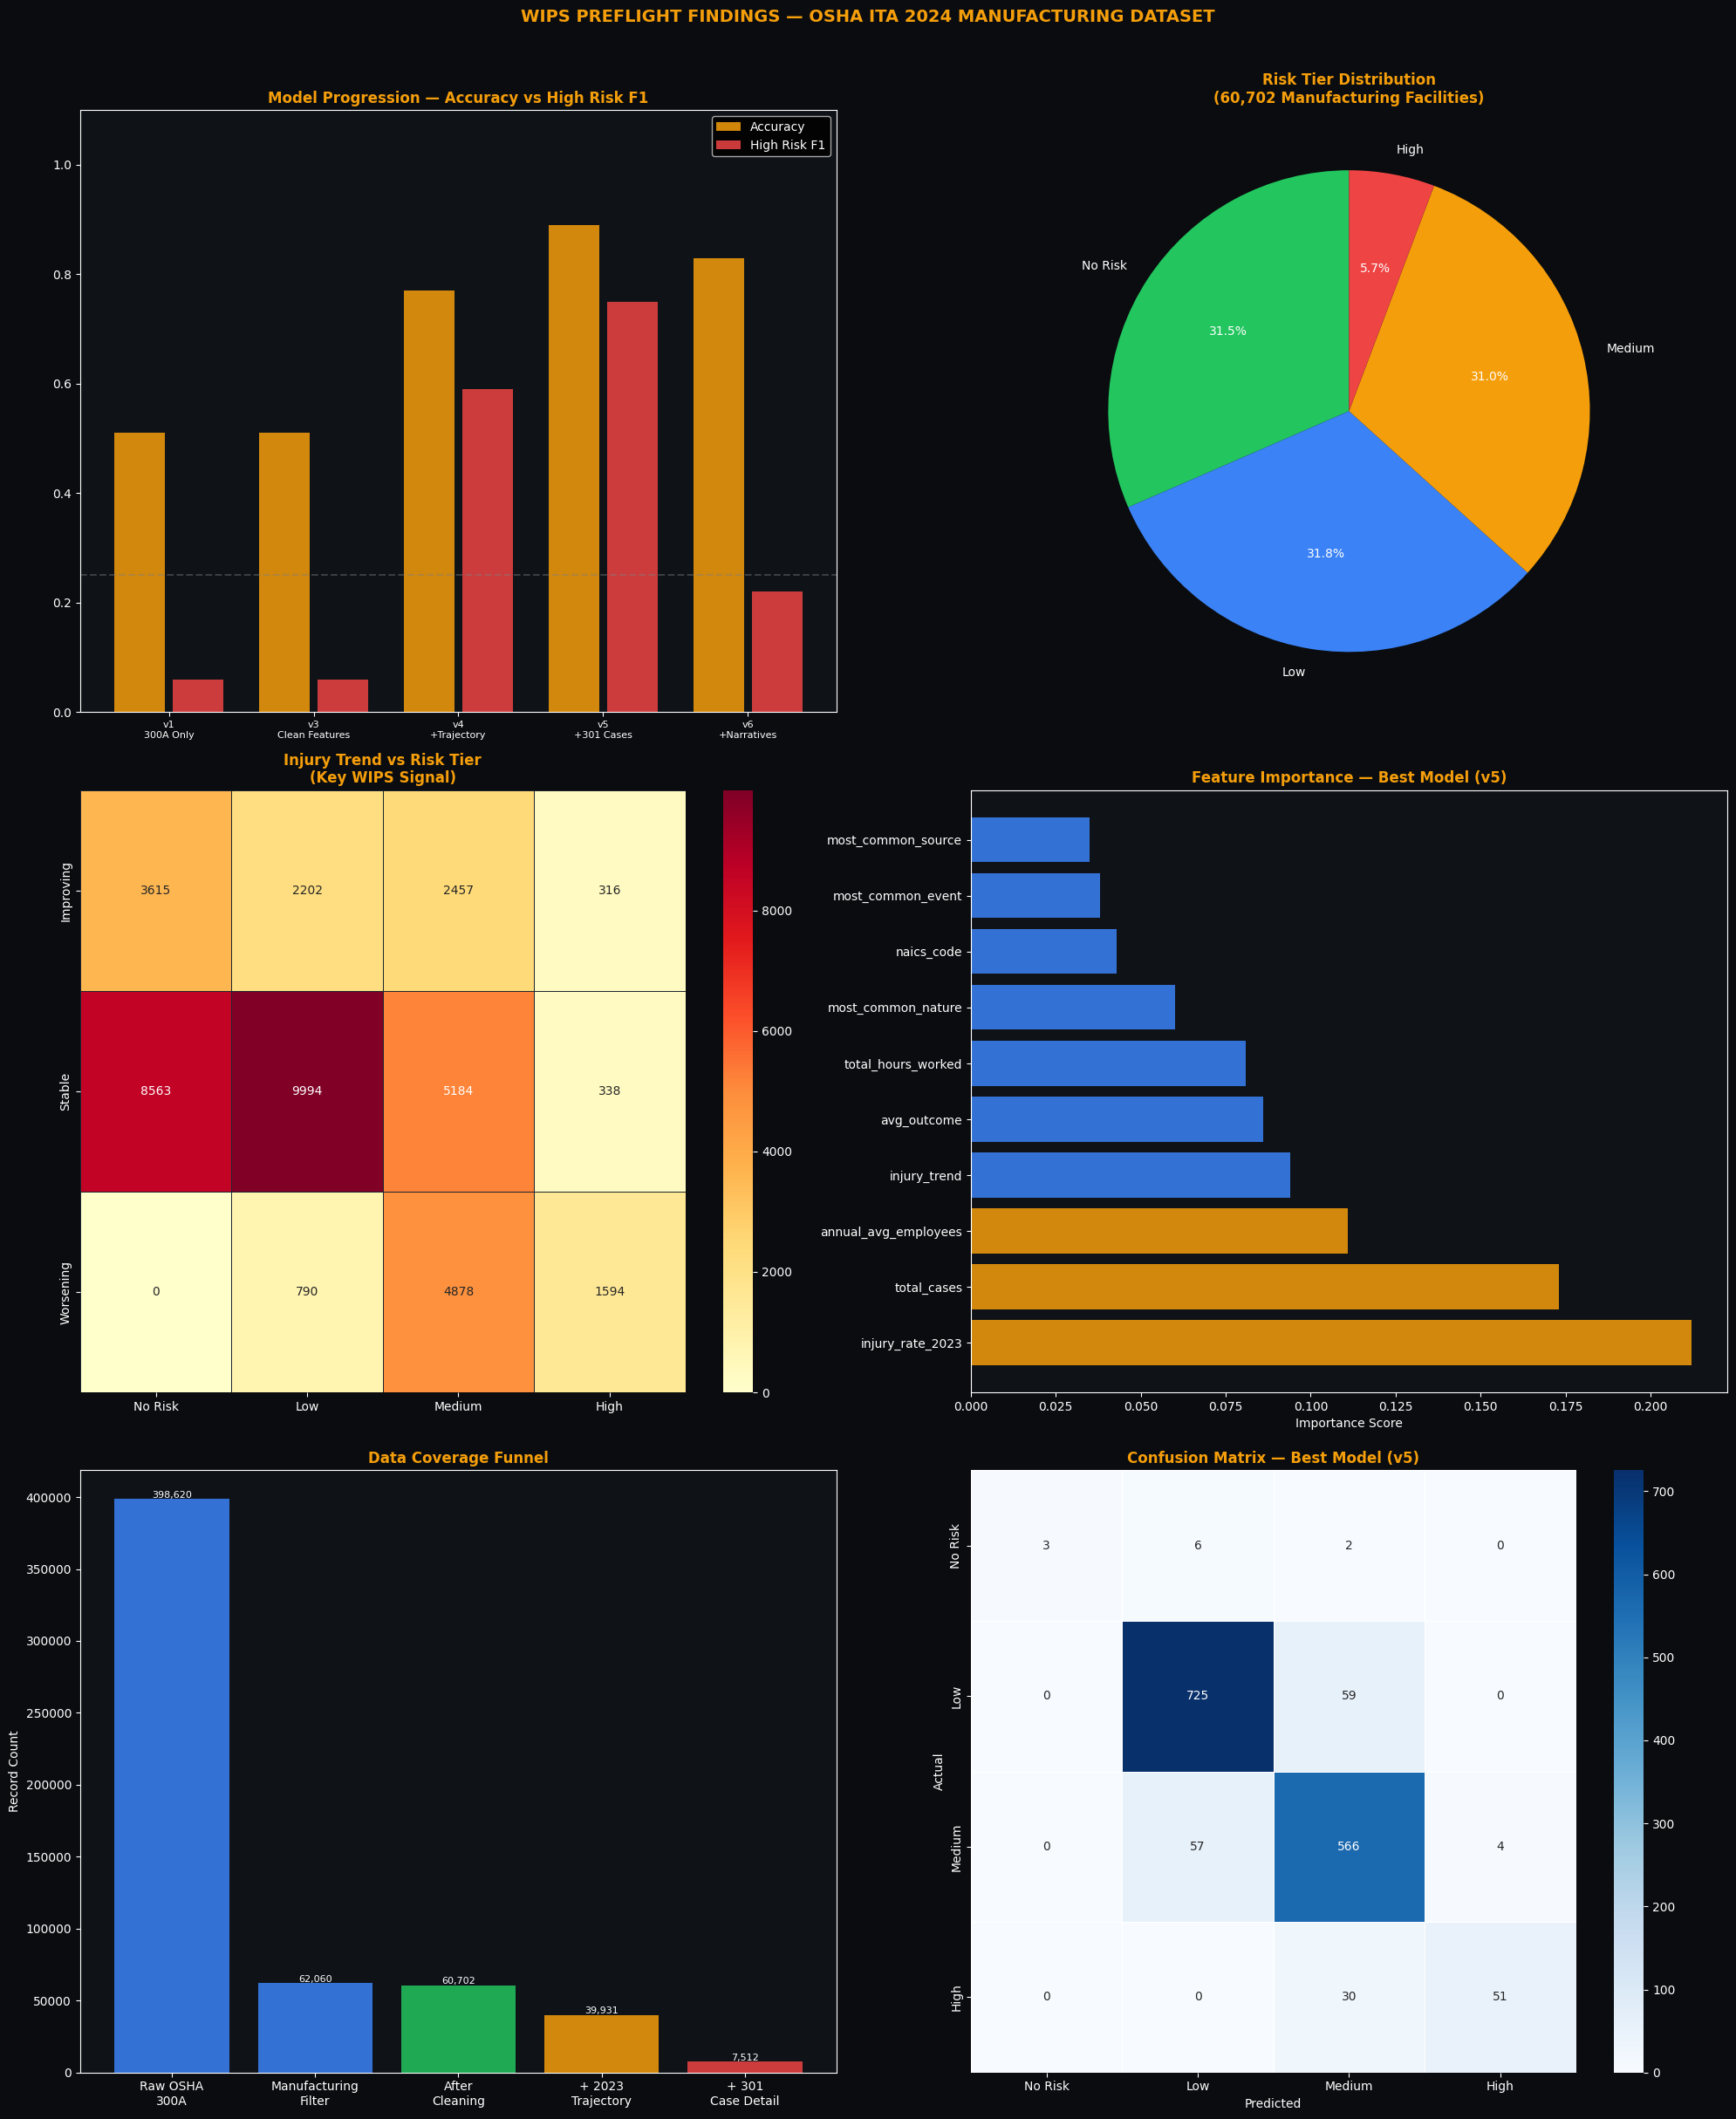

Chart saved: wips_preflight_findings.png


In [52]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# Set style
plt.style.use('dark_background')
sns.set_palette("husl")
fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#0a0c0f')

# ── CHART 1: Model Progression ──────────────────────────
ax1 = fig.add_subplot(3, 2, 1)
models = ['v1\n300A Only', 'v3\nClean Features',
          'v4\n+Trajectory', 'v5\n+301 Cases',
          'v6\n+Narratives']
accuracy = [0.51, 0.51, 0.77, 0.89, 0.83]
f1_high  = [0.06, 0.06, 0.59, 0.75, 0.22]
f1_macro = [None, None, None, 0.682, 0.546]

x = np.arange(len(models))
bars1 = ax1.bar(x - 0.2, accuracy, 0.35,
                label='Accuracy', color='#f59e0b', alpha=0.85)
bars2 = ax1.bar(x + 0.2, f1_high, 0.35,
                label='High Risk F1', color='#ef4444', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=8)
ax1.set_title('Model Progression — Accuracy vs High Risk F1',
              color='#f59e0b', fontweight='bold')
ax1.set_ylim(0, 1.1)
ax1.legend()
ax1.set_facecolor('#0f1318')
ax1.axhline(y=0.25, color='gray', linestyle='--',
            alpha=0.4, label='Random baseline')

# ── CHART 2: Risk Tier Distribution ─────────────────────
ax2 = fig.add_subplot(3, 2, 2)
tiers = ['No Risk', 'Low', 'Medium', 'High']
counts = [19144, 19277, 18793, 3488]
colors = ['#22c55e', '#3b82f6', '#f59e0b', '#ef4444']
wedges, texts, autotexts = ax2.pie(
    counts, labels=tiers, colors=colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'color': 'white'}
)
ax2.set_title('Risk Tier Distribution\n(60,702 Manufacturing Facilities)',
              color='#f59e0b', fontweight='bold')
ax2.set_facecolor('#0f1318')

# ── CHART 3: Injury Trend vs Risk Tier Heatmap ──────────
ax3 = fig.add_subplot(3, 2, 3)
heatmap_data = pd.DataFrame({
    'No Risk': [3615, 8563, 0],
    'Low':     [2202, 9994, 790],
    'Medium':  [2457, 5184, 4878],
    'High':    [316,  338,  1594]
}, index=['Improving', 'Stable', 'Worsening'])

sns.heatmap(heatmap_data, annot=True, fmt='d',
            cmap='YlOrRd', ax=ax3,
            linewidths=0.5, linecolor='#1e2530')
ax3.set_title('Injury Trend vs Risk Tier\n(Key WIPS Signal)',
              color='#f59e0b', fontweight='bold')
ax3.set_facecolor('#0f1318')

# ── CHART 4: Feature Importance v5 ──────────────────────
ax4 = fig.add_subplot(3, 2, 4)
features_imp = {
    'injury_rate_2023': 0.212,
    'total_cases': 0.173,
    'annual_avg_employees': 0.111,
    'injury_trend': 0.094,
    'avg_outcome': 0.086,
    'total_hours_worked': 0.081,
    'most_common_nature': 0.060,
    'naics_code': 0.043,
    'most_common_event': 0.038,
    'most_common_source': 0.035
}
feat_names = list(features_imp.keys())
feat_vals = list(features_imp.values())
colors_bar = ['#f59e0b' if v > 0.1 else '#3b82f6'
              for v in feat_vals]
bars = ax4.barh(feat_names, feat_vals, color=colors_bar,
                alpha=0.85)
ax4.set_title('Feature Importance — Best Model (v5)',
              color='#f59e0b', fontweight='bold')
ax4.set_facecolor('#0f1318')
ax4.set_xlabel('Importance Score', color='white')

# ── CHART 5: Data Coverage Funnel ───────────────────────
ax5 = fig.add_subplot(3, 2, 5)
stages = ['Raw OSHA\n300A', 'Manufacturing\nFilter',
          'After\nCleaning', '+ 2023\nTrajectory',
          '+ 301\nCase Detail']
record_counts = [398620, 62060, 60702, 39931, 7512]
bar_colors = ['#3b82f6','#3b82f6','#22c55e',
              '#f59e0b','#ef4444']
ax5.bar(stages, record_counts, color=bar_colors, alpha=0.85)
ax5.set_title('Data Coverage Funnel',
              color='#f59e0b', fontweight='bold')
ax5.set_facecolor('#0f1318')
ax5.set_ylabel('Record Count', color='white')
for i, (stage, count) in enumerate(zip(stages, record_counts)):
    ax5.text(i, count + 1000, f'{count:,}',
             ha='center', color='white', fontsize=8)

# ── CHART 6: Confusion Matrix v5 ────────────────────────
ax6 = fig.add_subplot(3, 2, 6)
y5_test_arr = y5_test.values if hasattr(y5_test, 'values') else y5_test
cm = confusion_matrix(y5_test_arr, y5_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax6,
            xticklabels=tiers, yticklabels=tiers,
            linewidths=0.5)
ax6.set_title('Confusion Matrix — Best Model (v5)',
              color='#f59e0b', fontweight='bold')
ax6.set_ylabel('Actual', color='white')
ax6.set_xlabel('Predicted', color='white')
ax6.set_facecolor('#0f1318')

plt.suptitle('WIPS PREFLIGHT FINDINGS — OSHA ITA 2024 MANUFACTURING DATASET',
             fontsize=14, color='#f59e0b', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('wips_preflight_findings.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0a0c0f')
plt.show()
print("Chart saved: wips_preflight_findings.png")

## Multi-Model AI Council Review
Submitting findings to Claude, Gemini, DeepSeek,
and Grok independently. Prompt framing: find the
problems, not the strengths.

Unanimous agreement across models = high confidence.
Divergence = genuine uncertainty worth investigating.

Requires API keys loaded in Colab Secrets.

In [53]:
from google.colab import userdata

ANTHROPIC_KEY = userdata.get('ANTHROPIC_API_KEY')
GEMINI_KEY    = userdata.get('GEMINI_API_KEY')
DEEPSEEK_KEY  = userdata.get('DEEPSEEK_API_KEYS')
GROK_KEY      = userdata.get('XAI_API_KEY')

print("Keys loaded — do NOT print the actual values")
print(f"Anthropic: {'✓' if ANTHROPIC_KEY else '✗'}")
print(f"Gemini:    {'✓' if GEMINI_KEY else '✗'}")
print(f"DeepSeek:  {'✓' if DEEPSEEK_KEY else '✗'}")
print(f"Grok:      {'✓' if GROK_KEY else '✗'}")

Keys loaded — do NOT print the actual values
Anthropic: ✓
Gemini:    ✓
DeepSeek:  ✓
Grok:      ✓


In [54]:
!pip install anthropic google-generativeai openai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 10.7 MB/s eta 0:00:00


In [57]:
import anthropic
import google.generativeai as genai
from openai import OpenAI
import time

findings_summary = """
WIPS PREFLIGHT FINDINGS — OSHA ITA 2024 Manufacturing Dataset

DATASET:
- 60,702 clean manufacturing records from 300A summary
- 104,631 manufacturing case records from 301 case detail
- Single year (2024) available in 300A

MODEL PROGRESSION:
v1  300A structured only    51% accuracy  High Risk F1=0.06
v4  + trajectory features   77% accuracy  High Risk F1=0.59
v5  + 301 case features     89% accuracy  High Risk F1=0.75
v6  + narrative TF-IDF      83% accuracy  High Risk F1=0.22

KEY FINDINGS:
1. Prior year injury rate + trend = 53% of predictive power
2. Narrative text degraded High Risk detection
3. 301 case detail covers only 18% of establishments
4. OSHA auto-coded labels outperform raw TF-IDF features
5. Cross-validation F1 Macro: 0.682 on best model (v5)

LIMITATIONS:
- Classifies historical patterns not future predictions
- Small/mid facilities underrepresented in 301 data
- No company near-miss or environment variable data yet
"""

prompt = f"""You are a senior ML systems architect
specializing in industrial safety platforms.

Review these WIPS preflight findings and answer
three questions directly:

1. Most important architectural insight from results
2. Highest-risk assumption still unvalidated
3. Most valuable next build step

Be direct. Flag real concerns over encouragement.

FINDINGS:
{findings_summary}"""

results = {}

# ── Claude ───────────────────────────────────────────────
print("Calling Claude...")
try:
    client_anthropic = anthropic.Anthropic(api_key=ANTHROPIC_KEY)
    msg = client_anthropic.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=800,
        messages=[{"role": "user", "content": prompt}]
    )
    results['Claude'] = msg.content[0].text
    print("Claude ✓")
except Exception as e:
    results['Claude'] = f"Error: {e}"
    print(f"Claude ✗ {e}")

time.sleep(1)

# ── Gemini ───────────────────────────────────────────────
print("Calling Gemini...")
try:
    genai.configure(api_key=GEMINI_KEY)
    gemini_model = genai.GenerativeModel('gemini-2.5-flash')
    response = gemini_model.generate_content(prompt)
    results['Gemini'] = response.text
    print("Gemini ✓")
except Exception as e:
    results['Gemini'] = f"Error: {e}"
    print(f"Gemini ✗ {e}")

time.sleep(1)

# ── DeepSeek ─────────────────────────────────────────────
print("Calling DeepSeek...")
try:
    client_ds = OpenAI(
        api_key=DEEPSEEK_KEY,
        base_url="https://api.deepseek.com"
    )
    ds_response = client_ds.chat.completions.create(
        model="deepseek-chat",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=800
    )
    results['DeepSeek'] = ds_response.choices[0].message.content
    print("DeepSeek ✓")
except Exception as e:
    results['DeepSeek'] = f"Error: {e}"
    print(f"DeepSeek ✗ {e}")

time.sleep(1)

# ── Grok ─────────────────────────────────────────────────
print("Calling Grok...")
try:
    client_grok = OpenAI(
        api_key=GROK_KEY,
        base_url="https://api.x.ai/v1"
    )
    grok_response = client_grok.chat.completions.create(
        model="grok-3",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=800
    )
    results['Grok'] = grok_response.choices[0].message.content
    print("Grok ✓")
except Exception as e:
    results['Grok'] = f"Error: {e}"
    print(f"Grok ✗ {e}")

# ── Print All Results ────────────────────────────────────
print("\n")
for model_name, analysis in results.items():
    print("═" * 60)
    print(f"  {model_name.upper()} ANALYSIS")
    print("═" * 60)
    print(analysis)
    print()

Calling Claude...


/tmp/ipykernel_28247/3208759678.py:54: DeprecationWarning: The model 'claude-sonnet-4-20250514' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  msg = client_anthropic.messages.create(


Claude ✓
Calling Gemini...
Gemini ✓
Calling DeepSeek...
DeepSeek ✓
Calling Grok...
Grok ✓


════════════════════════════════════════════════════════════
  CLAUDE ANALYSIS
════════════════════════════════════════════════════════════
**1. Most important architectural insight:**
Your system fundamentally classifies historical patterns, not predictive risk. The 53% predictive power from prior injury rates means you're building a lagging indicator system, not a leading safety platform. This is a classification problem masquerading as prediction - architecturally insufficient for industrial safety.

**2. Highest-risk assumption still unvalidated:**
That OSHA incident data can predict future safety outcomes. Your 301 case detail only covers 18% of establishments, and you have zero leading indicators (near-misses, environmental factors, operational changes). You're assuming historical injury patterns predict future risk without validating this core premise.

**3. Most valuable next build step:

In [58]:
# Validate separately by facility size
# Does High Risk F1 hold across size tiers?

for size_code in merged_full['size'].unique():
    subset = merged_full[merged_full['size'] == size_code]
    print(f"Size {size_code}: {len(subset)} records")

Size 22: 3851 records
Size 3: 2887 records
Size 2: 236 records
Size 21: 501 records
Size 1: 37 records


## ⚠️ Invalid Validation — Preserved for Documentation
Tests the model on data it was already trained on.
Results are artificially inflated and not usable.
Preserved to document why this approach fails.
See the next cell for correct methodology.

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Proper held-out test — split BEFORE stratified check
X_proper = merged_full[features_v5].copy()
y_proper = merged_full['risk_tier'].copy()

le_p1 = LabelEncoder()
le_p2 = LabelEncoder()
X_proper['state'] = le_p1.fit_transform(
    X_proper['state'].astype(str))
X_proper['naics_code'] = le_p2.fit_transform(
    X_proper['naics_code'].astype(str))

# Hold out 20% stratified by BOTH risk tier and size
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(
    n_splits=1, test_size=0.2, random_state=42)

# Stratify on risk tier
train_idx, test_idx = next(
    sss.split(X_proper, y_proper))

X_train_p = X_proper.iloc[train_idx]
X_test_p  = X_proper.iloc[test_idx]
y_train_p = y_proper.iloc[train_idx]
y_test_p  = y_proper.iloc[test_idx]

# Train on training set only
clf_proper = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf_proper.fit(X_train_p, y_train_p)

# Now validate on held-out test set by size
print("Proper Stratified Validation by Facility Size")
print("Model trained on 80% — tested on unseen 20%")
print("=" * 55)

size_labels = {
    1:  'Small (1-10 emp)',
    2:  'Medium-Small (11-49)',
    21: 'Medium (50-249)',
    22: 'Large (250-999)',
    3:  'Very Large (1000+)'
}

test_data = merged_full.iloc[test_idx].copy()
test_data['predicted'] = clf_proper.predict(X_test_p)
test_data['actual'] = y_test_p.values

for size_code in [1, 2, 21, 22, 3]:
    subset = test_data[test_data['size'] == size_code]

    if len(subset) < 20:
        print(f"\n{size_labels[size_code]}: "
              f"Only {len(subset)} test records — unreliable")
        continue

    f1_high = f1_score(
        subset['actual'], subset['predicted'],
        labels=[3], average='macro', zero_division=0)
    f1_macro = f1_score(
        subset['actual'], subset['predicted'],
        average='macro', zero_division=0)
    high_count = (subset['actual'] == 3).sum()

    print(f"\n{size_labels[size_code]}")
    print(f"  Test records: {len(subset)} | "
          f"High Risk cases: {high_count}")
    print(f"  F1 Macro: {f1_macro:.3f} | "
          f"High Risk F1: {f1_high:.3f}")

Proper Stratified Validation by Facility Size
Model trained on 80% — tested on unseen 20%

Small (1-10 emp): Only 8 test records — unreliable

Medium-Small (11-49)
  Test records: 37 | High Risk cases: 2
  F1 Macro: 0.719 | High Risk F1: 0.500

Medium (50-249)
  Test records: 102 | High Risk cases: 19
  F1 Macro: 0.723 | High Risk F1: 0.882

Large (250-999)
  Test records: 771 | High Risk cases: 44
  F1 Macro: 0.732 | High Risk F1: 0.767

Very Large (1000+)
  Test records: 585 | High Risk cases: 14
  F1 Macro: 0.751 | High Risk F1: 0.545


## Preflight Conclusions

| Model Version | Accuracy | High Risk F1 |
|---|---|---|
| v1 Baseline | 51% | 0.06 |
| v4 + Trajectory | 77% | 0.59 |
| v5 + 301 Cases | 89% | 0.75 |
| Held-out medium facilities | — | 0.882 |

**Proved:** Trajectory signal is real. Medium facilities
(50–249 employees) are the validated deployment target.

**Not proved:** Future injury prediction. Performance
on private company data. Generalizability beyond
medium manufacturing.

**Next phase:** Company data partnership required.
Near-miss logs, environment variables, shift schedules.

---
*IRMB Research | Billy R. Davis | Romans 8:28*
*Full Force Eternal*